s1_0.csv
s1_1.csv
s1_2.csv
s12_0.csv
s12_1.csv
s12_2.csv
s123_0.csv
s123_1.csv
s123_2.csv
s1234_0.csv
s1234_1.csv
s1234_2.csv
s34_0.csv
s34_1.csv
s34_2.csv


/var/folders/jn/bmqy_d4d2p3bd9jltzcfx_j00000gn/T/ipykernel_1069/996237896.py:34: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  method_df_mean = method_df.groupby("Step").mean().reset_index()
/var/folders/jn/bmqy_d4d2p3bd9jltzcfx_j00000gn/T/ipykernel_1069/996237896.py:35: FutureWarning: The default value of numeric_only in DataFrameGroupBy.std is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  method_df_std = method_df.groupby("Step").std().reset_index()
/var/folders/jn/bmqy_d4d2p3bd9jltzcfx_j00000gn/T/ipykernel_1069/996237896.py:34: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either s

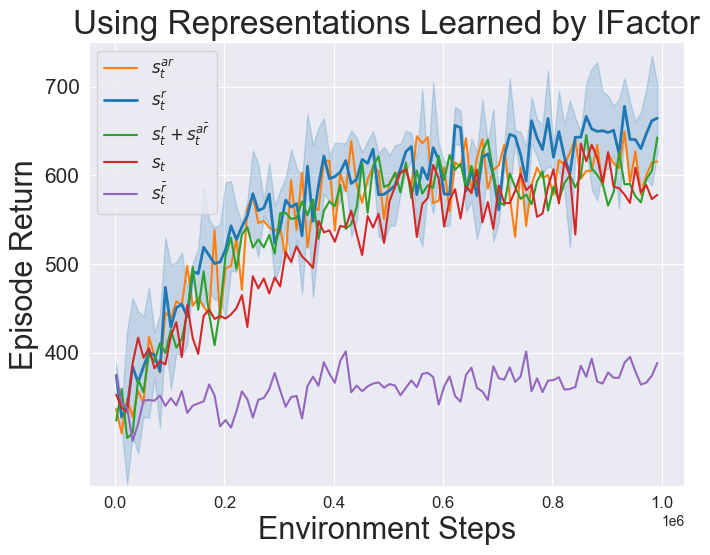

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
sns.set_style("darkgrid")
colors = sns.color_palette()

# color_list = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#e377c2','#7f7f7f']
def plot_mean_std(directory, interval=5):
    methods = ["s1", "s12", "s123", "s1234", "s34"]
    methods_label = {"s12": r'$s^{r}_t$', "s1": r'$s^{ar}_t$', "s123": r'$s^{r}_t + s^{a\bar{r}}_t $', "s34": r'$s^{\bar{r}}_t$', "s1234": r'$s_t $'}
    seeds = [0, 1, 2]

    all_data = []
    colori = 1
    for method in methods:
        method_data = []

        for seed in seeds:
            file_name = f"{method}_{seed}.csv"
            file_path = os.path.join(directory, file_name)

            if os.path.isfile(file_path):
                print(file_name)
                df = pd.read_csv(file_path)
                df = df.drop(columns="Wall time")
                df["Method"] = methods_label[method]
                method_data.append(df)

        if method_data:
            method_df = pd.concat(method_data)
            # method_df = method_df.iloc[::interval]
            method_df_mean = method_df.groupby("Step").mean().reset_index()
            method_df_std = method_df.groupby("Step").std().reset_index()
            # print(method_df_mean[:10])
            all_data.append(( methods_label[method], method_df_mean, method_df_std))

    # plt.figure(figsize=(6, 6))
    fig_width = 6.4
    fig_height = 4.8
    scale = 1.2
    plt.figure(figsize=(fig_width * scale, fig_height * scale))
    # fig, ax = plt.subplots(figsize=(6, 6.5))
    
    for method, mean_df, std_df in all_data:
        if method == '$s^{r}_t$':
            plt.plot(mean_df["Step"], mean_df["Value"], label=method, linewidth=2, color=colors[0])
            plt.fill_between(mean_df["Step"], mean_df["Value"] - std_df["Value"], mean_df["Value"] + std_df["Value"], alpha=0.2, color=colors[0])
        else:
            plt.plot(mean_df["Step"], mean_df["Value"], label=method, alpha=1, color=colors[colori])
            # plt.fill_between(mean_df["Step"], mean_df["Value"] - std_df["Value"], mean_df["Value"] + std_df["Value"], alpha=0.1, color=colors[colori])
            colori += 1
            
            
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
    plt.xlabel("Environment Steps", fontsize=22)
    plt.ylabel("Episode Return", fontsize=22)
    plt.ylim([250, 750])
    plt.yticks([400, 500, 600, 700] ,fontsize=15)
    plt.xticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.title("Using Representations Learned by IFactor", fontsize=24)

    plt.savefig(os.path.join(directory, "Robodesk_sac.pdf"))
    plt.show()

# Replace "your_directory" with the path to your directory containing the CSV files.
plot_mean_std("anonymized_path")
